# Les Timers

Un Timer est un compteur matériel indépendant du processeur qui compte les impulsions de l'horloge système interne $(F_{tim})$, préalablement divisée par un Prescaler (diviseur de fréquence). Il est configuré pour générer un signal (drapeau : *flag*) ou déclencher une interruption lorsqu'il atteint sa valeur maximale de basculement (débordement ou *Overflow*) indiquée dans le registre de période (`Auto-Reload`), ou une valeur de comparaison spécifique. 

Le temps écoulé entre son activation et le moment où le drapeau est levé peut être calculé. Ce mécanisme est plus précis temporellement et est non-bloquant pour le processeur. Il dépend de l'horloge interne (souvent stabilisée par un quartz) et non de la vitesse d'exécution du code.

Pour calculer le temps désiré exact, il faut calculer la durée d'un unique incrément (le Tick) ainsi que le nombre de pas nécessaires pour atteindre le délai souhaité. On utilise la formule : 

$$T_{tick}=\frac{\text{Prescaler}+1}{F_{tim}}$$

Sur STM32F401, le Prescaler possède une subtilité matérielle, la valeur réelle par laquelle l'horloge est divisée est égale à $(\text{Registre Prescaler} + 1)$. Pour un Timer 16 bits (comme TIM2, TIM3, TIM4 ou TIM5 qui est lui sur 32 bits), le temps maximal avant débordement $(T_{max})$ ou la période de mise à jour s'ajuste précisément grâce au registre `ARR` (*Auto-Reload Register*) qui définit le plafond du compteur :

$$T_{periode}=\frac{(\text{Prescaler}+1)\times (\text{ARR}+1)}{F_{tim}}$$

Ce mécanisme est configuré via plusieurs registres de 32 bits :
- `TIMx->PSC` : Le registre de *Prescaler* (diviseur d'horloge d'entrée pour ralentir le compteur).
- `TIMx->ARR` : Le registre de fin de comptage (*Auto-Reload Register*). Il définit la valeur maximale à atteindre avant de revenir à zéro (debordement). C'est a dire quand le compteur `CNT` atteint `ARR`, un événement de mise à jour (*update*) est généré, et `CNT` est remis à zéro (en mode *upcounting*). C'est le débordement.
- `TIMx->CNT` : Le registre de compteur (*Counter Register*) qui stocke la valeur actuelle en temps réel. Il s'incrémente à chaque coup d'horloge.
- `TIMx->SR` : Le registre de statut (*Status Register*), dont le bit `UIF` (*Update Interrupt Flag*) passe automatiquement à l'état haut lors du débordement pour signaler la fin du délai.
- `TIMx->CR1` : Le registre de contrôle (*Control Register 1*), dont le bit `CEN` (*Counter Enable*) permet d'allumer ou d'éteindre le Timer.

avec `x` représentant le numéro du Timer choisi (par exemple TIM2)

Toutes les variables partagées entre le programme principal `main` et modifiées au sein d'une routine d'interruption (ISR) doivent impérativement être déclarées avec le qualificatif `volatile`.

## Création de délais avec débordement : Clignotement précis avec delay-Timer

Ici, nous configurons le Timer 2 qui est de 32 bits avec une horloge par défaut à 16 MHz issue de l'oscillateur interne (HSI). Pour simplifier le calcul et éviter d'avoir à compter des dizaines de débordements successifs, nous ajustons directement les registres PSC et ARR pour obtenir un débordement unique toutes les 1 seconde (1000 ms).

Pour cela, nous configurons le Prescaler à 1599. Le Timer s'incrémente à une fréquence de :

$$\frac{16\,000\,000\text{\ Hz}}{1599+1}=10\,000\text{\ ticks/seconde}$$

Le registre de période ARR étant configuré à 9999, un débordement unique (`UIF`) survient exactement après 10 000 ticks, soit toutes les :

$$\frac{9999+1}{10\,000\text{\ Hz}}=1,000000\text{\ seconde}$$

```c
#include "stm32f4xx.h"

#define LED_PIN 13

void Timer2_Init() {
    // 1. Activer l'horloge du Timer 2 sur le bus APB1
    RCC->APB1ENR |= RCC_APB1ENR_TIM2EN;

    // Configurer le Prescaler (PSC) pour diviser l'horloge par 1600
    // Pour 16MHz : 16e6 / (1599 + 1) = 10000 incréments par seconde
    TIM2->PSC = 1600 - 1; 

    // Configurer la période (ARR) pour compter 10000 pas
    // 10000 ticks / 10000Hz = 1 débordement par seconde
    TIM2->ARR = 10000 - 1;

    // Forcer la mise à jour pour appliquer immédiatement PSC et ARR
    TIM2->EGR |= TIM_EGR_UG;

    // Activer le compteur (CEN = 1 dans CR1)
    TIM2->CR1 |= TIM_CR1_CEN;
}

// Fonction de délai non-bloquante pour les autres périphériques
// Mais bloquante localement pour la démonstration
void TIM2_Delay_1s() {
    // On attend que le flag UIF (Update Interrupt Flag) soit levé
    while (!(TIM2->SR & TIM_SR_UIF)) {
        __NOP();
    }
    
    // On remet le flag à 0 manuellement (sur STM32, on applique un masque inverse)
    TIM2->SR &= ~TIM_SR_UIF;
}

int main() {
    // Initialisation de la LED de la Black Pill (PC13) en sortie
    RCC->AHB1ENR |= RCC_AHB1ENR_GPIOCEN;
    GPIOC->MODER &= ~(3U << (LED_PIN * 2));
    GPIOC->MODER |=  (1U << (LED_PIN * 2));
    GPIOC->BSRR = (1U << LED_PIN); // Éteinte au départ (Anode commune)

    Timer2_Init();

    while(1) {
        // On appelle notre délai basé sur le matériel
        TIM2_Delay_1s();
        
        GPIOC->ODR ^= (1U << LED_PIN); // Toggle LED
    }
    return 0;
}
```

Bien que l'exemple ci-dessus utilise le matériel pour mesurer le temps avec precision, mais la fonction `TIM2_Delay_1s()` contient toujours une boucle `while` d'attente active qui bloque le processeur.

Pour libérer pleinement la puissance du microcontrôleur dans une application multitâche, nous devons lier ce Timer au contrôleur d'interruptions. Ainsi, au lieu de surveiller le registre `TIM2->SR`, le matériel exécutera automatiquement une fonction dès que le temps sera écoulé.


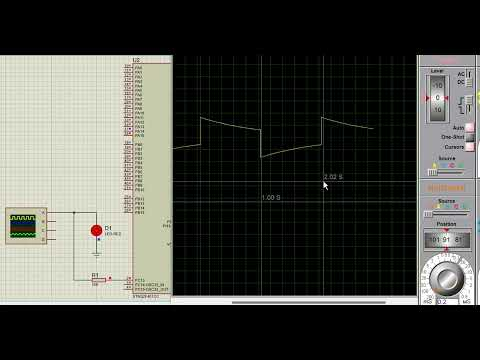

In [15]:
from IPython.display import YouTubeVideo

# Remplacez l'identifiant ci-dessous par celui de votre vidéo
YouTubeVideo('XBCwYPPZzio', width=800, height=450)



### Exemple 2 : Anti-rebond (Debounce) avec Interruption et Timer

Les stratégies utilisées ici :

- L'appui matériel sur le bouton déclenche une Interruption Externe (`EXTI0`).
- Dans cette interruption, on désactive temporairement la ligne `EXTI0` pour ignorer toutes les impulsions parasites immédiates, et on lance un compte à rebours sur un Timer matériel.
- Le Timer 3 attend 20 ms (le temps que le signal électrique se stabilise) puis confirme l'appui. Pendant ce temps, la boucle `main()` exécute d'autres tâches.
- L'interruption du Timer 3 se déclenche après 20 ms. Elle vérifie si le bouton est toujours enfoncé. Si oui, l'appui est validé. Elle réactive enfin l'interruption du bouton.

Détail du calcul pour 20 ms (Timer 3 - 16 bits). Pour une fréquence d'horloge système de 16 MHz (HSI) et un Prescaler configuré à 1599 (division réelle par 1600) :

$$F_{tim}=\frac{16\,000\,000\text{\ Hz}}{1599+1}=10\,000\text{\ Hz}$$

$$\text{Période\ d}^{\prime }\text{un\ tick}=\frac{1}{10\,000\text{\ Hz}}=0,0001\text{\ s}\ (100\ \mu \text{s})$$

$$\text{Nombre\ de\ ticks\ pour\ 20\ ms}=\frac{0,020\text{\ s}}{0,0001\text{\ s}}=200\text{\ ticks}$$

On configure donc le registre de période ARR du Timer 3 à 199 (199 + 1 = 200 pas).

```c
#include "stm32f4xx.h"

#define LED_PIN     13
#define BTN_PORT    GPIOA
#define BTN_PIN     0

// Variable volatile car modifiée sous interruption et lue dans le main
volatile uint8_t bouton_valide = 0;

void GPIO_Init(void) {
    // 1. Activer l'horloge pour les ports A et C
    RCC->AHB1ENR |= RCC_AHB1ENR_GPIOAEN | RCC_AHB1ENR_GPIOCEN;

    // Configuration de la LED PC13 (Sortie push-pull)
    GPIOC->MODER &= ~(3U << (LED_PIN * 2));   
    GPIOC->MODER |=  (1U << (LED_PIN * 2));   
    GPIOC->BSRR = (1U << LED_PIN); // LED éteinte au départ (Anode commune)

    // Configuration du bouton PA0 (Entrée avec Pull-up)
    BTN_PORT->MODER &= ~(3U << (BTN_PIN * 2)); // Mode entrée (00)
    BTN_PORT->PUPDR &= ~(3U << (BTN_PIN * 2)); // Reset
    BTN_PORT->PUPDR |=  (1U << (BTN_PIN * 2)); // Active la résistance de Pull-up
}

void Interrupt_Init(void) {
    // 2. Activer l'horloge du bloc SYSCFG (indispensable pour l'EXTI)
    RCC->APB2ENR |= RCC_APB2ENR_SYSCFGEN;

    // 3. Connecter la ligne EXTI0 au port A (PA0)
    SYSCFG->EXTICR[0] &= ~SYSCFG_EXTICR1_EXTI0;

    // 4. Configurer la ligne EXTI0 sur front descendant (Falling edge = appui au GND)
    EXTI->FTSR |= (1 << 0);
    EXTI->RTSR &= ~(1 << 0); // Désactiver le front montant

    // 5. Démasquer l'interruption locale pour la ligne EXTI0
    EXTI->IMR |= (1 << 0);

    // 6. Activer l'interruption EXTI0 dans le NVIC
    NVIC_SetPriority(EXTI0_IRQn, 1); // Priorité forte
    NVIC_EnableIRQ(EXTI0_IRQn);
}

void Timer3_Init(void) {
    // 1. Activer l'horloge du Timer 3 sur le bus APB1
    RCC->APB1ENR |= RCC_APB1ENR_TIM3EN;

    // 2. Configurer le Prescaler pour cadencer le compteur à 10 kHz
    TIM3->PSC = 1599; 

    // 3. Configurer l'ARR pour obtenir une période de 20 ms (200 ticks)
    TIM3->ARR = 199;

    // 4. Activer l'interruption locale de mise à jour (Update Interrupt Enable)
    TIM3->DIER |= TIM_DIER_UIE;

    // 5. Configurer l'interruption globale TIM3 dans le NVIC (sans lancer le compteur)
    NVIC_SetPriority(TIM3_IRQn, 2); // Priorité légèrement inférieure à l'EXTI
    NVIC_EnableIRQ(TIM3_IRQn);
}

int main(void) {
    GPIO_Init();
    Interrupt_Init();
    Timer3_Init();

    while(1) {
        if(bouton_valide) {
            // Action à réaliser après un appui propre, asynchrone et filtré
            GPIOC->ODR ^= (1U << LED_PIN); // Action : Changement d'état de la LED
            bouton_valide = 0;              // Reset du flag logiciel
        }
        // Le processeur peut faire d'autres calculs complexes ici en continu 
        // sans jamais être perturbé ou gelé par les rebonds du bouton.
    }
    return 0;
}

// 1. Détection de l'appui physique initial
void EXTI0_IRQHandler(void) {
    if (EXTI->PR & (1 << 0)) {
        EXTI->PR = (1 << 0); // Effacer le flag d'interruption matériel

        EXTI->IMR &= ~(1 << 0); // Désactiver l'interruption bouton pour masquer les rebonds
        
        TIM3->CNT = 0;          // Remettre le compteur du Timer 3 à zéro
        TIM3->CR1 |= TIM_CR1_CEN; // Lancer le Timer 3 (Compte à rebours de 20ms)
    }
}

// 2. Confirmation après 20ms (Fin des vibrations mécaniques)
void TIM3_IRQHandler(void) {
    if (TIM3->SR & TIM_SR_UIF) {
        TIM3->SR &= ~TIM_SR_UIF; // Effacer le flag matériel du Timer

        TIM3->CR1 &= ~TIM_CR1_CEN; // 1. Arrêter le Timer 3 (sa mission est finie)
        
        // 2. Vérifier l'état électrique stable de la broche PA0 (Bouton enfoncé = 0V)
        if ((BTN_PORT->IDR & (1 << BTN_PIN)) == 0) {
            bouton_valide = 1; // 3. Valider l'appui pour la boucle principale main()
        }
        
        EXTI->PR = (1 << 0);   // 4. Nettoyer le flag EXTI0 au cas où un rebond tardif l'aurait levé
        EXTI->IMR |= (1 << 0); // 5. Réactiver l'interruption bouton, prête pour le prochain appui
    }
}

```

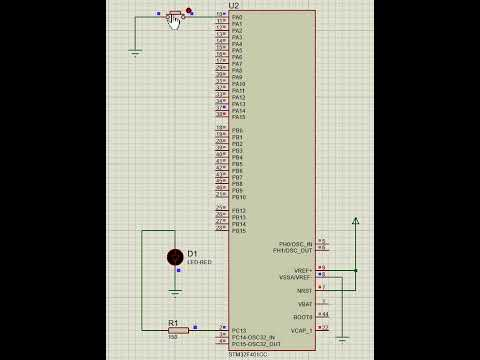

In [37]:
from IPython.display import YouTubeVideo

# Remplacez l'identifiant ci-dessous par celui de votre vidéo
YouTubeVideo('GLnzqnRdpWw', width=800, height=450)

## Interruptions périodiques

Pour supprimer définitivement l'attente active du processeur et rendre notre système réellement multitâche, nous devons lier le débordement du Timer au contrôleur d'interruptions du processeur (NVIC).

Sur le STM32F401, le Timer possède un registre dédié à l'autorisation des événements, le registre `TIMx->DIER` (*DMA/Interrupt Enable Register*). En y activant le bit `UIE` (*Update Interrupt Enable*), le matériel va générer automatiquement une requête d'interruption vers le `NVIC` à chaque fois que le compteur atteint la valeur du registre `ARR` (débordement). Le NVIC prend alors le relais, suspend le programme principal, et exécute la routine dédiée nommée `TIM2_IRQHandler`.

Les règles impératives dans l'ISR du Timer :

- L'acquittement du flag (`UIF`) : le drapeau de mise à jour `UIF` dans le registre `TIM2->SR` doit impérativement être remis à `0` à la main dès l'entrée dans l'ISR. Si on oublie cette ligne, l'interruption restera active en permanence, bloquant instantanément le reste du code.
- Le qualificatif `volatile` : Toute variable lue dans le main et modifiée dans `TIM2_IRQHandler` doit porter le mot-clé `volatile` pour empêcher le compilateur d'optimiser sa valeur dans les registres CPU.


### Exemple :  Clignotement non-bloquant

Dans cet exemple, l'initialisation configure les registres pour obtenir un tick à 10 kHz et une période d'exactement 1 seconde (1000 ms), puis démasque l'interruption locale et globale. La boucle `while(1)` du programme principal reste totalement vide et disponible pour d'autres calculs.

```c
#include "stm32f4xx.h"

#define LED_PIN 13

// Compteur global de secondes partagé, modifié uniquement sous interruption
volatile uint32_t seconds_elapsed = 0;

void Timer2_IRQ_Init(void) {
    // 1. Activer l'horloge du Timer 2 sur le bus APB1
    RCC->APB1ENR |= RCC_APB1ENR_TIM2EN;

    // 2. Configurer le Prescaler (PSC) pour diviser l'horloge par 1600
    // Fréquence d'entrée (16 MHz) / (1599 + 1) = 10 000 Ticks par seconde
    TIM2->PSC = 1599; 

    // 3. Configurer la période (ARR) pour compter 10 000 pas
    // 10 000 ticks / 10 000 Hz = 1 interruption de débordement par seconde
    TIM2->ARR = 9999;

    // 4. Activer l'interruption locale de mise à jour (Update Interrupt Enable)
    TIM2->DIER |= TIM_DIER_UIE;

    // 5. Forcer la mise à jour pour charger immédiatement PSC, ARR et effacer les flags initiaux
    TIM2->EGR |= TIM_EGR_UG;
    TIM2->SR &= ~TIM_SR_UIF; // Sécurité : s'assurer que le flag est bien à 0 avant de démarrer

    // 6. Configurer la priorité et activer l'interruption globale TIM2 dans le NVIC
    NVIC_SetPriority(TIM2_IRQn, 2); // Priorité intermédiaire (0 étant la plus haute)
    NVIC_EnableIRQ(TIM2_IRQn);

    // 7. Activer le compteur (CEN = 1 dans CR1)
    TIM2->CR1 |= TIM_CR1_CEN;
}

// Handler de l'interruption matérielle du Timer 2
void TIM2_IRQHandler(void) {
    // Vérification de sécurité : l'interruption provient-elle bien d'un débordement (Update) ?
    if (TIM2->SR & TIM_SR_UIF) {
        
        // OBLIGATOIRE : Effacer immédiatement le flag d'interruption matériel
        TIM2->SR &= ~TIM_SR_UIF;

        // Traitement applicatif : inversion directe de la LED toutes les secondes
        GPIOC->ODR ^= (1U << LED_PIN); 

        // Exemple alternatif : incrémentation de notre compteur global
        seconds_elapsed++;
    }
}

int main(void) {
    // Initialisation de la LED de la Black Pill (PC13) en sortie
    RCC->AHB1ENR |= RCC_AHB1ENR_GPIOCEN;
    GPIOC->MODER &= ~(3U << (LED_PIN * 2));
    GPIOC->MODER |=  (1U << (LED_PIN * 2));
    GPIOC->BSRR = (1U << LED_PIN); // LED Éteinte au départ (Anode commune)

    // Lancement du Timer sous interruption
    Timer2_IRQ_Init();

    while(1) {
        // La boucle principale est libre à 100% !
        // Le processeur peut exécuter d'autres tâches en tâche de fond.
        // Le clignotement de la LED est entièrement géré par le matériel.
        __WFI(); // Optionnel : met le CPU en sommeil léger en attendant la prochaine interruption
    }
    return 0;
}
```




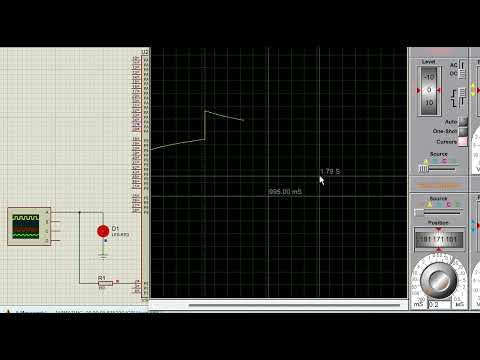

In [33]:
from IPython.display import YouTubeVideo

# Remplacez l'identifiant ci-dessous par celui de votre vidéo
YouTubeVideo('l6ko95VhIbU', width=800, height=450)

## Pilotage d'un afficheur 7 segments


Pour obtenir un déclenchement précis sans bloquer le processeur, nous configurons Timer 0 pour générer une interruption environ toutes les 2 millisecondes.  À chaque interruption, le microcontrôleur change de chiffre (multiplexage dynamique), laissant la boucle principale while(1) totalement libre pour exécuter d'autres tâches. Une machine à états bascule d'un afficheur à l'autre à chaque interruption. Les 4 afficheurs sont ainsi rafraîchis en moins de 10 millisecondes (fréquence globale > 100 Hz), ce qui est parfait pour tromper l'œil humain sans aucun scintillement.

L'utilisation de l'opérateur modulo % remplace les soustractions complexes pour extraire les chiffres de manière plus propre.

### Exemple 1 : Chronometre 7 segments

Le Timer 2 gère la base de temps précise de 1 ms en arrière-plan, sans blocage du processeur. Nous disposons d'un tableau constant qui contient le motif d'allumage des LED pour un afficheur 7 segments à cathode commune.

**Détail du calcul pour 1 ms (Timer 2 - 32 bits)**

Pour une fréquence d'horloge interne par défaut à 16 MHz (HSI) et un Prescaler configuré à 15 (division réelle par 16) :

$$F_{tim}=\frac{16\,000\,000\text{\ Hz}}{15+1}=1\,000\,000\text{\ Hz}\ (1\text{\ MHz})$$

$$\text{Période\ d}^{\prime }\text{un\ tick}=\frac{1}{1\,000\,000\text{\ Hz}}=0,000001\text{\ s}\ (1\ \mu \text{s})$$

$$\text{Nombre\ de\ ticks\ pour\ 1\ ms}=\frac{0,001\text{\ s}}{0,000001\text{\ s}}=1000\text{\ ticks}$$

On configure donc le registre de période ARR du Timer 2 à 999 (999 + 1 = 1000 pas).


```c
#include "stm32f4xx.h"

// Motifs d'allumage pour afficheur 7 segments (Cathode commune)
// Associés consécutivement aux broches PA0 (Segment A) jusqu'à PA7 (Segment DP)
const uint8_t DIGITS[] = {
    0x3F, 0x06, 0x5B, 0x4F, 0x66, 0x6D, 0x7D, 0x07, 0x7F, 0x6F
};

// Variable volatile car modifiée sous interruption et lue dans le main
volatile uint16_t millisecondes = 0;

void GPIO_Init(void) {
    // 1. Activer l'horloge pour le Port A
    RCC->AHB1ENR |= RCC_AHB1ENR_GPIOAEN;

    // 2. Configurer les broches PA0 à PA7 en mode Sortie Générale (01)
    // On nettoie d'abord les bits [15:0] de MODER puis on applique le masque de sortie
    GPIOA->MODER &= ~(0xFFFFU << 0);
    GPIOA->MODER |=  (0x5555U << 0); // 0x5555 correspond à 0101010101010101 binaire
}

void Timer2_Init_1ms(void) {
    // 1. Activer l'horloge du Timer 2 sur le bus APB1
    RCC->APB1ENR |= RCC_APB1ENR_TIM2EN;

    // 2. Configurer le Prescaler (PSC) pour obtenir une fréquence de 1 MHz
    TIM2->PSC = 15; 

    // 3. Configurer la période (ARR) pour obtenir un débordement toutes les 1 ms
    TIM2->ARR = 999;

    // 4. Activer l'interruption locale de mise à jour (Update Interrupt Enable)
    TIM2->DIER |= TIM_DIER_UIE;

    // 5. Forcer la mise à jour pour charger immédiatement les registres
    TIM2->EGR |= TIM_EGR_UG;
    TIM2->SR &= ~TIM_SR_UIF; // Nettoyer le flag initial provoqué par l'EGR

    // 6. Configurer la priorité et activer l'interruption TIM2 dans le NVIC
    NVIC_SetPriority(TIM2_IRQn, 2);
    NVIC_EnableIRQ(TIM2_IRQn);

    // 7. Activer le compteur
    TIM2->CR1 |= TIM_CR1_CEN;
}

// Interruption du Timer 2 toutes les 1 ms
void TIM2_IRQHandler(void) {
    // On vérifie la source du débordement
    if (TIM2->SR & TIM_SR_UIF) {
        TIM2->SR &= ~TIM_SR_UIF; // OBLIGATOIRE : Effacer le drapeau matériel

        millisecondes++; // Incrémentation du compteur de temps en arrière-plan
    }
}

int main(void) {
    uint8_t compteur = 0;

    // Initialisations matérielles
    GPIO_Init();
    Timer2_Init_1ms();

    while(1) {
        // Mise à jour de l'afficheur en écrivant sur la partie basse du port A (PA0..PA7)
        GPIOA->ODR = DIGITS[compteur];

        // Vérification asynchrone et non bloquante du temps écoulé
        if (millisecondes >= 1000) {
            millisecondes = 0; // Reset de la base de temps
            compteur++;        // Passage au chiffre suivant
            
            if (compteur > 9) {
                compteur = 0;  // Retour à zéro après le chiffre 9
            }
        }
        
        // Le processeur reste disponible ici pour d'autres traitements en simultané
    }
    return 0;
}

```



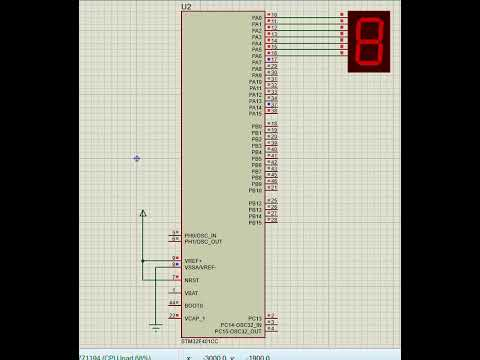

In [39]:
from IPython.display import YouTubeVideo

# Remplacez l'identifiant ci-dessous par celui de votre vidéo
YouTubeVideo('kRCQ1h7pWOQ', width=800, height=450)

### Exemple 2 : Chronomètre numérique (Multiplexage temporel)

Les segments (A à G) sont reliés aux broches PA0 à PA6 (Port A), et la sélection des 4 afficheurs se fait via les broches PB2, PB3, PB4 et PB5 (Port B).

```c
#include "stm32f4xx.h"

// Table de correspondance : Index (0-9) -> Code des segments (A à G)
// Configuration pour afficheur à Cathode Commune (1 = Segment allumé)
const uint8_t SEGMENTS[] = {
    0x3F, // Chiffre 0
    0x06, // Chiffre 1
    0x5B, // Chiffre 2
    0x4F, // Chiffre 3
    0x66, // Chiffre 4
    0x6D, // Chiffre 5
    0x7D, // Chiffre 6
    0x07, // Chiffre 7
    0x7F, // Chiffre 8
    0x6F  // Chiffre 9
};

// Variables globales pour stocker temporairement chaque chiffre découpé
volatile uint8_t chiffre_unites         = 0;
volatile uint8_t chiffre_dizaines       = 0;
volatile uint8_t chiffre_centaines      = 0;
volatile uint8_t chiffre_unites_millier = 0;

// Fonction pédagogique pour découper un nombre entier en 4 chiffres distincts
void developper_nombre_en_chiffres(int nombre_a_afficher) {
    chiffre_unites_millier =  nombre_a_afficher / 1000;
    chiffre_centaines      = (nombre_a_afficher % 1000) / 100;
    chiffre_dizaines       = (nombre_a_afficher % 100) / 10;
    chiffre_unites         =  nombre_a_afficher % 10;
}

// Petite fonction pour initialiser les broches des segments et des afficheurs
void GPIO_Init(void) {
    // Activer les horloges pour le Port A et le Port B
    RCC->AHB1ENR |= RCC_AHB1ENR_GPIOAEN | RCC_AHB1ENR_GPIOBEN;

    // PORTA : Configuration des broches PA0 à PA6 en SORTIES (Contrôle des segments A à G)
    GPIOA->MODER &= ~(0x3FFFU); // Efface les bits de PA0 à PA6
    GPIOA->MODER |=  (0x1555U); // Configure PA0 à PA6 en mode Sortie (binaire 01)
    
    // PORTB : Configuration des broches PB2, PB3, PB4, PB5 en SORTIES (Sélection des afficheurs)
    GPIOB->MODER &= ~((3U << (2 * 2)) | (3U << (3 * 2)) | (3U << (4 * 2)) | (3U << (5 * 2)));
    GPIOB->MODER |=  ((1U << (2 * 2)) | (1U << (3 * 2)) | (1U << (4 * 2)) | (1U << (5 * 2)));
}

// Petite fonction pour configurer le Timer 2 afin de générer une interruption toutes les 2 ms
void Timer2_Init(void) {    
    // CONFIGURATION DU TIMER 2 (32 bits)
    // Objectif : Générer une interruption toutes les 2 ms.
    // Fréquence du Timer : 16 MHz / (PSC + 1) = 16 MHz / 16 = 1 000 000 Hz (1 MHz).
    // Nombre de pas pour atteindre 2 ms : 1 000 000 Hz * 0.002 s = 2000 ticks.
    RCC->APB1ENR |= RCC_APB1ENR_TIM2EN; // Activer l'horloge du Timer 2
    // Fréquence du Timer : 16 MHz / (15 + 1) = 1 000 000 Hz (1 MHz).
    TIM2->PSC = 15;                     // Division par 16
    // Nombre de pas pour atteindre 2 ms : 1 000 000 Hz * 0.002 s = 2000 ticks (de 0 à 1999).
    TIM2->ARR = 1999;                   // 2000 pas (de 0 à 1999)
    TIM2->DIER |= TIM_DIER_UIE;         // Autoriser l'interruption locale de mise à jour (UIE)

    // Forcer la mise à jour pour appliquer immédiatement les registres
    TIM2->EGR |= TIM_EGR_UG;
    TIM2->SR &= ~TIM_SR_UIF;

    // Activation globale au niveau du NVIC et démarrage du compteur
    NVIC_EnableIRQ(TIM2_IRQn);
    TIM2->CR1 |= TIM_CR1_CEN;
}

// Routine d'interruption du Timer 2 (Appelée automatiquement toutes les 2 ms)
void TIM2_IRQHandler(void) {
    if (TIM2->SR & TIM_SR_UIF) {
        TIM2->SR &= ~TIM_SR_UIF; // OBLIGATOIRE : Effacer le drapeau matériel

        // Variable statique pour mémoriser quel afficheur doit s'allumer au prochain tour
        static uint8_t afficheur_actif = 0;

        // ÉTAPE 1 : Anti-ghosting (Extinction temporaire de tous les afficheurs)
        // On force les broches PB2, PB3, PB4 et PB5 à l'état BAS (0) via le registre ODR
        GPIOB->ODR &= ~((1U << 2) | (1U << 3) | (1U << 4) | (1U << 5));

        // ÉTAPE 2 : Commutation de l'afficheur (Multiplexage temporel)
        switch(afficheur_actif) {
            case 0:
                GPIOA->ODR = SEGMENTS[chiffre_unites]; // Envoi des segments sur PA0..PA6
                GPIOB->ODR |= (1U << 2);               // Allumage de l'afficheur 1 (PB2)
                afficheur_actif = 1;                   // Préparation du prochain afficheur
                break;
                
            case 1:
                GPIOA->ODR = SEGMENTS[chiffre_dizaines];
                GPIOB->ODR |= (1U << 3);               // Allumage de l'afficheur 2 (PB3)
                afficheur_actif = 2;
                break;
                
            case 2:
                GPIOA->ODR = SEGMENTS[chiffre_centaines];
                GPIOB->ODR |= (1U << 4);               // Allumage de l'afficheur 3 (PB4)
                afficheur_actif = 3;
                break;
                
            case 3:
                GPIOA->ODR = SEGMENTS[chiffre_unites_millier];
                GPIOB->ODR |= (1U << 5);               // Allumage de l'afficheur 4 (PB5)
                afficheur_actif = 0;                   // Retour au premier afficheur
                break;
        }
    }
}

int main(void) {
		// Initialisations du matériel via nos petites fonctions
    GPIO_Init();
    Timer2_Init();

    // VARIABLES DU PROGRAMME PRINCIPAL
    int compteur_affichage = 0;       // Valeur numérique à afficher (0 à 9999)
    uint32_t temporisation_boucle = 0; // Variable pour remplacer la fonction bloquante delay()

    // Initialisation du premier affichage
    developper_nombre_en_chiffres(compteur_affichage);

    while(1) {
        // Cette condition crée un rythme d'environ 500ms sans figer le microcontrôleur.
        // Le STM32 étant très rapide, la valeur cible est augmentée par rapport à l'AVR.
        if (temporisation_boucle >= 40000) { 
            compteur_affichage++; // Incrémentation du compteur
            
            if(compteur_affichage >= 10000) {
                compteur_affichage = 0; // Remise à zéro si on dépasse 9999
            }
            
            // Mise à jour des variables lues en arrière-plan par le Timer 2
            developper_nombre_en_chiffres(compteur_affichage);
            
            temporisation_boucle = 0; // Réinitialisation du rythme de la boucle
        }
        
        temporisation_boucle++; // Incrémentation continue
        // Le processeur peut faire d'autres calculs ici en continu, l'affichage reste fluide.
    }
    return 0;
}

```

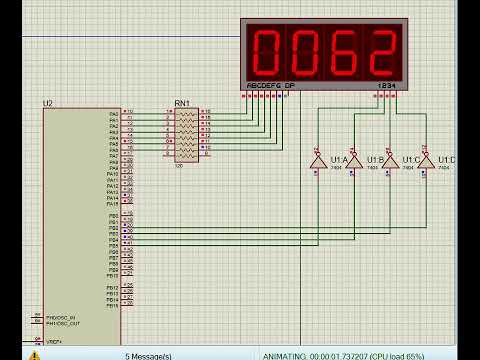

In [41]:
from IPython.display import YouTubeVideo

# Remplacez l'identifiant ci-dessous par celui de votre vidéo
YouTubeVideo('IudErcPC6tw', width=800, height=450)